In [3]:
# CELL 1: Essential Imports + Setup

import os

# Must be set BEFORE importing torch or matplotlib — prevents the OMP Error #15
# kernel crash we hit in the dataloader notebook
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import importlib
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Set project root path
# PROJECT_ROOT = r'C:\Users\aliyu\Desktop\architectural-inductive-bias-study'
PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# CHOOSE YOUR CONFIG HERE
CONFIG_MODULE = 'configs.flower_mlp'  # change to either of the config
config_module = importlib.import_module(CONFIG_MODULE)
CONFIG = config_module.CONFIG

from core_modules.model import build_model
from core_modules.dataloader import get_dataloaders

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {device}")

# Confirm CONFIG loaded
print("✓ CONFIG loaded:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

✓ Using device: cuda
✓ CONFIG loaded:
  dataset: flowers
  model_name: mlp
  num_classes: 5
  batch_size: 64
  epochs: 40
  lr: 0.001
  input_size: 128
  device: cuda
  project_root: C:\Users\aliyu\Desktop\autodl-fs
  train_dir: C:\Users\aliyu\Desktop\autodl-fs\datasets/flowers/train
  val_dir: C:\Users\aliyu\Desktop\autodl-fs\datasets/flowers/val
  test_dir: C:\Users\aliyu\Desktop\autodl-fs\datasets/flowers/test
  phase1_augmentation: light
  weight_decay: 0.0005
  dropout_rate: 0.3
  adam_beta1: 0.9
  adam_beta2: 0.999
  adam_eps: 1e-08
  label_smoothing: 0.1
  early_stopping_patience: 6
  mlp_hidden_sizes: [128, 64]


In [4]:
# CELL 2: Initialize Model + Load Data

# Use phase-specific augmentation
CONFIG['augmentation'] = CONFIG.get('phase1_augmentation', 'light')
print(f"📦 Using '{CONFIG['augmentation']}' augmentation for Phase 1")

# Load dataloaders from config — now returns 4 values (train, val, test, class_names)
train_loader, val_loader, test_loader, class_names = get_dataloaders(config=CONFIG)
num_classes = len(class_names)

# Initialize model — build_model() now only takes device + config;
# num_classes comes from CONFIG internally, fine_tune was removed since it
# was specific to pretrained EfficientNet backbones (not used for CNN/MLP/RNN)
model = build_model(
    device=CONFIG['device'],
    config=CONFIG
)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG['label_smoothing'])

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
    betas=(CONFIG['adam_beta1'], CONFIG['adam_beta2']),
    eps=CONFIG['adam_eps']
)

# Scheduler — will reduce LR on plateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

# Checkpoint directory (automatically separated by dataset + model)
checkpoint_dir = os.path.join(CONFIG['project_root'], 'experiments', CONFIG['dataset'], CONFIG['model_name'], 'checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)

📦 Using 'light' augmentation for Phase 1
Model: MLP
Model Configuration:
├── Trainable params: 6,300,165
├── Frozen params: 0
└── Output head: Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=49152, out_features=128, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU(inplace=True)
  (6): Dropout(p=0.3, inplace=False)
  (7): Linear(in_features=64, out_features=5, bias=True)
)



In [13]:
# CELL 3 (Optional): Resume from Checkpoint (if exists)

import os
import torch

model_path = os.path.join(CONFIG['project_root'], 'experiments', CONFIG['dataset'], CONFIG['model_name'],'models','trained_model.pth') #remove 'models', that is before 'trained_model.pth'

resume_training = False

if os.path.exists(model_path):
    print("Found saved model. Loading to resume training...")

    model = build_model(
        device=device,
        config=CONFIG,
        checkpoint_path=model_path
    )
    resume_training = True
    print("✓ Model loaded. Training will resume from last checkpoint.")
else:
    print("⚠️ No saved model found. Starting training from scratch.")

⚠️ No saved model found. Starting training from scratch.


In [14]:
# CELL 4: Training Setup
import datetime
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# Loss and optimizer already defined in Cell 2 — no need to redefine unless you want to reset them
# If you plan to support resume training with optimizer state, you can add logic here later
scaler = GradScaler()  # New line

print(f"\n✓ Training initialized.")

# Log directory setup (TensorBoard skipped — not used)
# log_dir = os.path.join(CONFIG['project_root'], 'experiments', CONFIG['dataset'], CONFIG['model_name'], 'tf-logs', 'run_' + datetime.datetime.now().strftime('%Y%m%d_%H%M%S'))
# os.makedirs(log_dir, exist_ok=True)
# writer = SummaryWriter(log_dir=log_dir)
# print(f"- TensorBoard logs: {log_dir}")  # Optional

# Checkpoint directory — already created in Cell 2, but safe to ensure here
checkpoint_dir = os.path.join(CONFIG['project_root'], 'experiments', CONFIG['dataset'], CONFIG['model_name'], 'checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)



✓ Training initialized.


Using light augmentation for Phase 1
Epoch 1/40, Train Loss: 1.5737, Val Loss: 1.5295, Train Acc: 0.286, Val Acc: 0.354
✓ Checkpoint saved: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\rnn\checkpoints\model_epoch_1.pth
✓ New best model saved to: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\rnn\models\best_model_phase1.pth
✓ Final model copied to: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\rnn\models\trained_model.pth
Epoch 2/40, Train Loss: 1.4802, Val Loss: 1.4383, Train Acc: 0.371, Val Acc: 0.383
✓ Checkpoint saved: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\rnn\checkpoints\model_epoch_2.pth
✓ New best model saved to: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\rnn\models\best_model_phase1.pth
✓ Final model copied to: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\rnn\models\trained_model.pth
Epoch 3/40, Train Loss: 1.4122, Val Loss: 1.4026, Train Acc: 0.414, Val Acc: 0.417
✓ Checkpoint saved: C:\Users\aliyu\Desktop\autodl-fs\experim

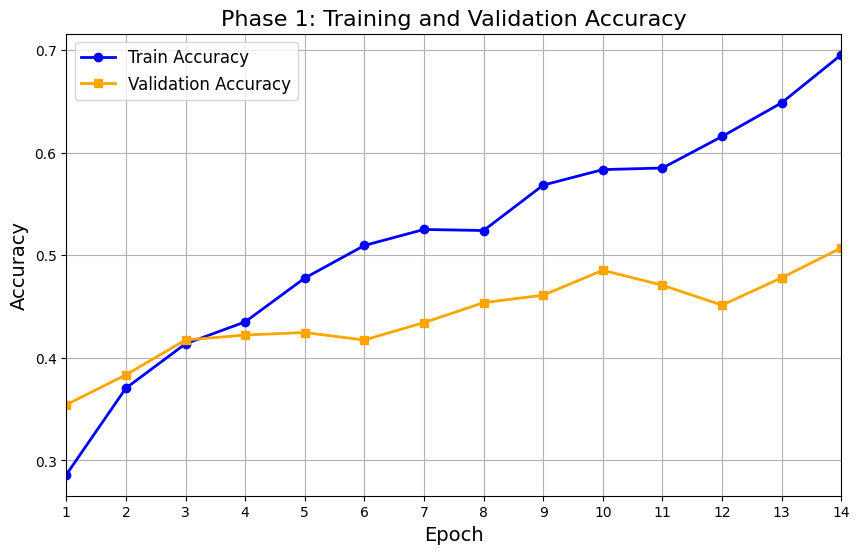

✓ Accuracy plot saved to: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\rnn\plots\train_val_metrics\phase1_accuracy_curve_epoch14.png


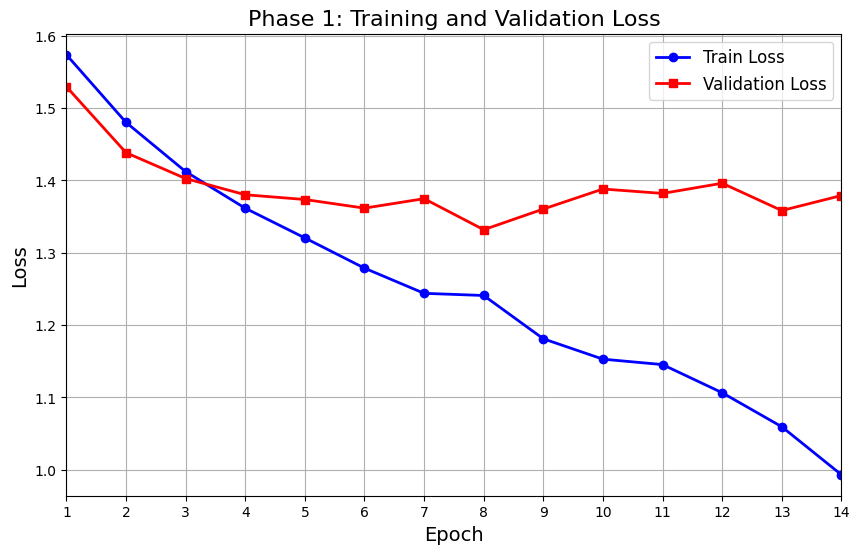

✓ Loss plot saved to: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\rnn\plots\train_val_metrics\phase1_loss_curve_epoch14.png


In [15]:
# CELL 5: Phase 1 - Training Loop with Logging and Best Model Save

import matplotlib.pyplot as plt
import os
import time

start_time = time.time()  # Start timer

print(f"Using {CONFIG['augmentation']} augmentation for Phase 1")

# Track metrics
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

# Early stopping setup
best_val_loss = float('inf')
patience, patience_counter = CONFIG['early_stopping_patience'], 0

# Training loop
for epoch in range(CONFIG['epochs']):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Skip batch if loss is NaN or inf
        if not torch.isfinite(loss):
            print(f"⚠️ Skipping batch {i} due to invalid loss: {loss.item()}")
            continue

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total


    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}/{CONFIG['epochs']}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Acc: {train_acc:.3f}, Val Acc: {val_acc:.3f}")

    # Save checkpoint (per epoch)
    checkpoint_path = os.path.join(CONFIG['project_root'], 'experiments', CONFIG['dataset'], CONFIG['model_name'], 'checkpoints', f'model_epoch_{epoch+1}.pth')
    torch.save(model.state_dict(), checkpoint_path)
    print(f"✓ Checkpoint saved: {checkpoint_path}")

    models_dir = os.path.join(CONFIG['project_root'], 'experiments', CONFIG['dataset'], CONFIG['model_name'], 'models')
    os.makedirs(models_dir, exist_ok=True)

    # Save best model (Phase 1)
    best_model_path = os.path.join(models_dir, 'best_model_phase1.pth')
    trained_model_path = os.path.join(models_dir, 'trained_model.pth')
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'state_dict': model.state_dict(),
            'class_names': class_names,
            'config': CONFIG
        }, best_model_path)
        torch.save({
            'state_dict': model.state_dict(),
            'class_names': class_names,
            'config': CONFIG
        }, trained_model_path)
        print(f"✓ New best model saved to: {best_model_path}")
        print(f"✓ Final model copied to: {trained_model_path}")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"⚠️ No improvement for {patience_counter} epoch(s).")
        if patience_counter >= patience:
            print(f"🛑 Early stopping triggered after {epoch+1} epochs.")
            break

# Training time summary
end_time = time.time()
total_time = end_time - start_time
minutes = total_time // 60
seconds = total_time % 60
print(f"\n🕒 Phase 1 training time: {int(minutes)} min {int(seconds)} sec")

summary_path = os.path.join(CONFIG['project_root'], 'experiments', CONFIG['dataset'], CONFIG['model_name'], 'training_summary.txt')
with open(summary_path, 'w') as f:
    f.write("=== Training Summary (Phase 1) ===\n")
    f.write(f"Model: {CONFIG['model_name'].upper()}\n")   # <-- fixed line
    f.write(f"Dataset: {CONFIG['dataset']}\n")
    f.write(f"Batch size: {CONFIG['batch_size']}\n")
    f.write(f"Epochs: {CONFIG['epochs']}\n")
    f.write(f"Final Train Acc: {train_acc_list[-1]:.4f}\n")
    f.write(f"Final Val Acc: {val_acc_list[-1]:.4f}\n")
    f.write(f"Final Train Loss: {train_loss_list[-1]:.4f}\n")
    f.write(f"Final Val Loss: {val_loss_list[-1]:.4f}\n")
    f.write(f"Phase 1 training time: {int(minutes)} min {int(seconds)} sec\n")
print(f"✓ Phase 1 summary saved to: {summary_path}")


# Save Accuracy and Loss Plots

base_plot_dir = os.path.join(CONFIG['project_root'], 'experiments', CONFIG['dataset'], CONFIG['model_name'], 'plots')
plot_dir = os.path.join(base_plot_dir, 'train_val_metrics')
os.makedirs(base_plot_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

epochs_range = list(range(1, len(train_loss_list) + 1))

if len(train_acc_list) >= 2:
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, train_acc_list, label="Train Accuracy", color='blue', marker='o', linewidth=2)
    plt.plot(epochs_range, val_acc_list, label="Validation Accuracy", color='orange', marker='s', linewidth=2)

    # NEW: Show only the epochs that actually ran
    plt.xlim(1, len(epochs_range))
    if len(epochs_range) <= 20:
        plt.xticks(epochs_range)

    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.title('Phase 1: Training and Validation Accuracy', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True)

    acc_path = os.path.join(plot_dir, f'phase1_accuracy_curve_epoch{len(epochs_range)}.png')
    plt.savefig(acc_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Accuracy plot saved to: {acc_path}")

if len(train_loss_list) >= 2:
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, train_loss_list, label="Train Loss", color='blue', marker='o', linewidth=2)
    plt.plot(epochs_range, val_loss_list, label="Validation Loss", color='red', marker='s', linewidth=2)

    # NEW: Show only the epochs that actually ran
    plt.xlim(1, len(epochs_range))
    if len(epochs_range) <= 20:
        plt.xticks(epochs_range)

    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Phase 1: Training and Validation Loss', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True)

    loss_path = os.path.join(plot_dir, f'phase1_loss_curve_epoch{len(epochs_range)}.png')
    plt.savefig(loss_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Loss plot saved to: {loss_path}")